# Identification des Dimensions Latentes de Compétence Académique avec PROC PRINCOMP

## Résumé

Une équipe d'évaluation d'un district scolaire utilise l'analyse en composantes principales pour réduire six scores de tests scolaires corrélés à quelques dimensions latentes interprétables. À partir de la matrice de corrélation de 100 élèves, l'analyse retrouve exactement deux composantes significatives : un axe dominant d'**aptitude académique générale** (valeur propre 3,93, 65,5 % de la variance) qui charge positivement sur chaque matière, et un **contraste verbal-versus-quantitatif** (valeur propre 1,60, 26,7 %) qui sépare lecture/écriture/vocabulaire de mathématiques/sciences/logique. Ensemble, les deux premières composantes expliquent **92,3 %** de la variance, et les quatre valeurs propres restantes se situent près du plancher de bruit de 0,07–0,14. La même structure à deux dimensions survit après élimination de l'effet de l'assiduité, confirmant que les dimensions sont des compétences intrinsèques plutôt qu'un artefact d'exposition. Le jeu `OUTSTAT=` sauvegardé donne au district une règle figée pour noter les futures cohortes sur les mêmes axes.

## Sources de données

| Jeu de données | Lignes | Description |
|---------|------|-------------|
| `WORK.STUDENTS` | 100 | Une ligne par élève. Six scores d'évaluation standardisés générés à partir de deux facteurs latents (aptitude académique générale et une tendance verbale/quantitative) plus du bruit propre à chaque matière, avec des champs démographiques associés. L'étape DATA demande 600 élèves, mais cet environnement non licencié plafonne la sortie à 100 observations — l'analyse ci-dessous porte sur les 100 premiers. |

**Variables de `WORK.STUDENTS`**

| Variable | Type | Description |
|----------|------|-------------|
| `student_id` | Num | Identifiant unique de l'élève (1001+) |
| `grade` | Num | Niveau scolaire (6-8) |
| `reading` | Num | Score de compréhension écrite |
| `writing` | Num | Score d'écriture / composition |
| `vocabulary` | Num | Score de vocabulaire |
| `math` | Num | Score de mathématiques |
| `science` | Num | Score de sciences |
| `logic` | Num | Score de raisonnement logique |
| `attendance_rate` | Num | Fraction de jours de présence (0-1), utilisée comme covariable à éliminer |

# Identification des Dimensions Latentes de Compétence Académique avec PROC PRINCOMP

Les programmes d'évaluation scolaire rapportent généralement de nombreux scores par matière pour chaque élève, mais ces scores sont fortement corrélés : les bons lecteurs ont aussi tendance à bien écrire et bien raisonner. Pour l'évaluation des programmes et le reporting, il est souvent plus utile de résumer chaque élève par quelques dimensions **non corrélées** que par six scores de matières qui se recoupent.

Ce notebook utilise `PROC PRINCOMP` pour :

1. Réduire six scores d'évaluation corrélés à un petit nombre de composantes principales.
2. Interpréter les composantes principales (un axe d'aptitude générale et un contraste verbal-vs-quantitatif).
3. Reporter les identifiants d'élèves sur les scores de composantes pour le reporting en aval.
4. Sauvegarder les charges des vecteurs propres avec `OUTSTAT=` afin qu'une nouvelle cohorte puisse être projetée sur les mêmes axes.
5. Éliminer l'effet de l'assiduité pour confirmer que la structure des composantes n'est pas un simple artefact d'exposition.

> **Une note sur la procédure.** SAS propose une variante haute performance, `PROC HPPRINCOMP`, qui ajuste le modèle identique sur une grille distribuée. Le `HPPRINCOMP` de Jenner est actuellement une ébauche de surface qui reproduit ses instructions sans calculer la décomposition, donc cet exemple utilise le moteur `PROC PRINCOMP` pleinement implémenté — les mathématiques, valeurs propres et charges sont identiques. L'écart est suivi par le test moteur `tests/400922_nb_hpprincomp_computes_no_eigenvalues_or_scores` ; une fois `HPPRINCOMP` relié au moteur réel, le mot-clé `PROC HPPRINCOMP` pourra être substitué sans autre changement.

## Étape 1 — Générer une cohorte synthétique d'évaluation d'élèves

Nous simulons une cohorte de collège. Chaque élève a deux traits latents :

- **`g`** — aptitude académique générale, qui élève chaque matière.
- **`vq`** — une tendance verbale-versus-quantitative qui pousse les scores de langue vers le haut tout en tirant les scores STEM vers le bas (et inversement).

Les scores de matières observés sont construits comme des combinaisons pondérées de ces traits latents plus du bruit propre à chaque matière, puis placés sur une échelle de score familière (moyenne ~500, écart-type ~40). Comme les données sont générées à partir de deux facteurs, nous nous attendons à ce que l'ACP retrouve environ deux composantes significatives. L'étape DATA boucle 600 fois, mais le moteur non licencié n'écrit que les 100 premières lignes — largement suffisant pour retrouver une structure à deux facteurs propre.

In [1]:
DONNÉES students;
    APPELER streaminit(20260531);
    FAIRE i = 1 JUSQU_À 600;
        student_id = 1000 + i;
        grade = 6 + floor(rand('uniform') * 3);   /* grades 6,7,8 */

        /* Two standardized latent traits */
        g  = rand('normal');                       /* general ability   */
        vq = rand('normal');                       /* verbal vs quant    */

        /* Subject scores: scaled to mean ~500, sd ~40.
           Verbal subjects load + on vq; STEM subjects load - on vq. */
        reading    = 500 + 40*(0.80*g + 0.55*vq) + 12*rand('normal');
        writing    = 500 + 40*(0.78*g + 0.50*vq) + 12*rand('normal');
        vocabulary = 500 + 40*(0.75*g + 0.60*vq) + 12*rand('normal');
        math       = 500 + 40*(0.82*g - 0.55*vq) + 12*rand('normal');
        science    = 500 + 40*(0.79*g - 0.45*vq) + 12*rand('normal');
        logic      = 500 + 40*(0.85*g - 0.10*vq) + 12*rand('normal');

        /* Attendance: mildly related to general ability */
        attendance_rate = MIN(1, MAX(0.6,
                          0.93 + 0.02*g + 0.03*rand('normal')));

        SORTIE;
    FIN;
    SUPPRIMER i g vq;
EXÉCUTER;


NOTE: DATA students

NOTE: Unlicensed mode - output limited to 100 observations.

NOTE: Wrote students (100 rows, 9 columns).
NOTE: DATA elapsed:
  wall  0.11 seconds
  cpu   0.11 seconds


In [2]:
PROCÉDURE IMPRIMER DONNÉES=students(obs=8) noobs ÉTIQUETTE;
    TITRE "Échantillon de relevés d'évaluation synthétiques des élèves";
    VAR student_id grade reading writing vocabulary
        math science logic attendance_rate;
    format reading writing vocabulary math science logic 5.1
           attendance_rate 5.3;
    ÉTIQUETTE student_id="Identifiant élève" grade="Niveau" reading="Lecture"
        writing="Écriture" vocabulary="Vocabulaire" math="Mathématiques"
        science="Sciences" logic="Logique" attendance_rate="Taux de présence";
EXÉCUTER;
TITRE;


                              Échantillon de relevés d'évaluation synthétiques des élèves                               

  Identifiant élève  Niveau  Lecture   Écriture  Vocabulaire   Mathématiques  Sciences  Logique   Taux de présence
               1001       8    498.7      526.2        513.9           521.6     515.1    507.7              0.903
               1002       6    480.7      485.6        492.9           472.6     479.9    470.6              0.881
               1003       6    485.0      487.8        478.1           538.3     535.6    490.0              0.994
               1004       7    466.0      499.1        494.7           474.9     507.2    484.2              0.930
               1005       8    504.2      489.0        508.0           546.3     558.9    521.6              0.946
               1006       7    537.4      551.6        532.1           521.7     540.2    527.1              0.958
               1007       7    402.6      414.3        434.1           42


NOTE: PROC PRINT data=students

NOTE: PROC PRINT completed: 8 observations printed, 9 variables


## Étape 2 — Analyse en composantes principales de référence sur la matrice de corrélation

Nous analysons les six scores de matières avec l'extraction par défaut (décomposition en valeurs propres de la matrice de **corrélation**). Travailler à partir de la matrice de corrélation standardise les matières, ce qui est le bon choix ici même si tous les scores partagent déjà une échelle, car cela empêche une seule matière de dominer simplement par une variance plus grande.

Nous exécutons d'abord la solution complète (sans `N=`) afin que le spectre complet des valeurs propres soit visible. Les valeurs propres et la proportion cumulée de variance nous indiquent combien de composantes retenir ; les vecteurs propres nous indiquent comment les interpréter. La matrice de corrélation imprimée préfigure déjà la structure : lecture/écriture/vocabulaire sont corrélées à ~0,88 entre elles, mathématiques/sciences/logique sont corrélées à ~0,77–0,89 entre elles, mais les deux blocs ne sont corrélés qu'à ~0,23–0,36 entre eux.

                       The PRINCOMP Procedure

                    Observations         100
                    Variables              6

                       Simple Statistics

Variable            Mean          StdDev

reading        494.46032        38.35596
writing        499.02018        38.28856
vocabulary     495.51805        37.64642
math           499.75555        41.31746
science        500.01392        37.80359
logic          496.47898        33.80841

                    Correlation Matrix

                reading   writing  vocabulary      math   science     logic

reading          1.0000    0.8870      0.8950    0.2589    0.3568    0.6253
writing          0.8870    1.0000      0.8817    0.2601    0.3664    0.6355
vocabulary       0.8950    0.8817      1.0000    0.2267    0.2740    0.5848
math             0.2589    0.2601      0.2267    1.0000    0.8920    0.7710
science          0.3568    0.3664      0.2740    0.8920    1.0000    0.7950
logic            0.6253    0.6355 


NOTE: PROC PRINCOMP data=students

NOTE: Using Python sklearn version 1.8.0
NOTE: Eigenvalues of the Correlation Matrix:
NOTE:   SkillPC1: Eigenvalue=3.932513  Proportion=0.6554  Cumulative=0.6554
NOTE:   SkillPC2: Eigenvalue=1.603834  Proportion=0.2673  Cumulative=0.9227
NOTE:   SkillPC3: Eigenvalue=0.144736  Proportion=0.0241  Cumulative=0.9468
NOTE:   SkillPC4: Eigenvalue=0.137703  Proportion=0.0230  Cumulative=0.9698
NOTE:   SkillPC5: Eigenvalue=0.109050  Proportion=0.0182  Cumulative=0.9880
NOTE:   SkillPC6: Eigenvalue=0.072163  Proportion=0.0120  Cumulative=1.0000
NOTE: Eigenvectors:
NOTE:   Variable       SkillPC1   SkillPC2   SkillPC3   SkillPC4   SkillPC5   SkillPC6
NOTE:   reading        -0.428183    0.358114   -0.218417    0.144590   -0.714215   -0.331208
NOTE:   writing        -0.429009    0.349423   -0.345339   -0.356536    0.601535   -0.292631
NOTE:   vocabulary     -0.411844    0.401597    0.330890    0.501120    0.210099    0.514153
NOTE:   math           -0.340844   -

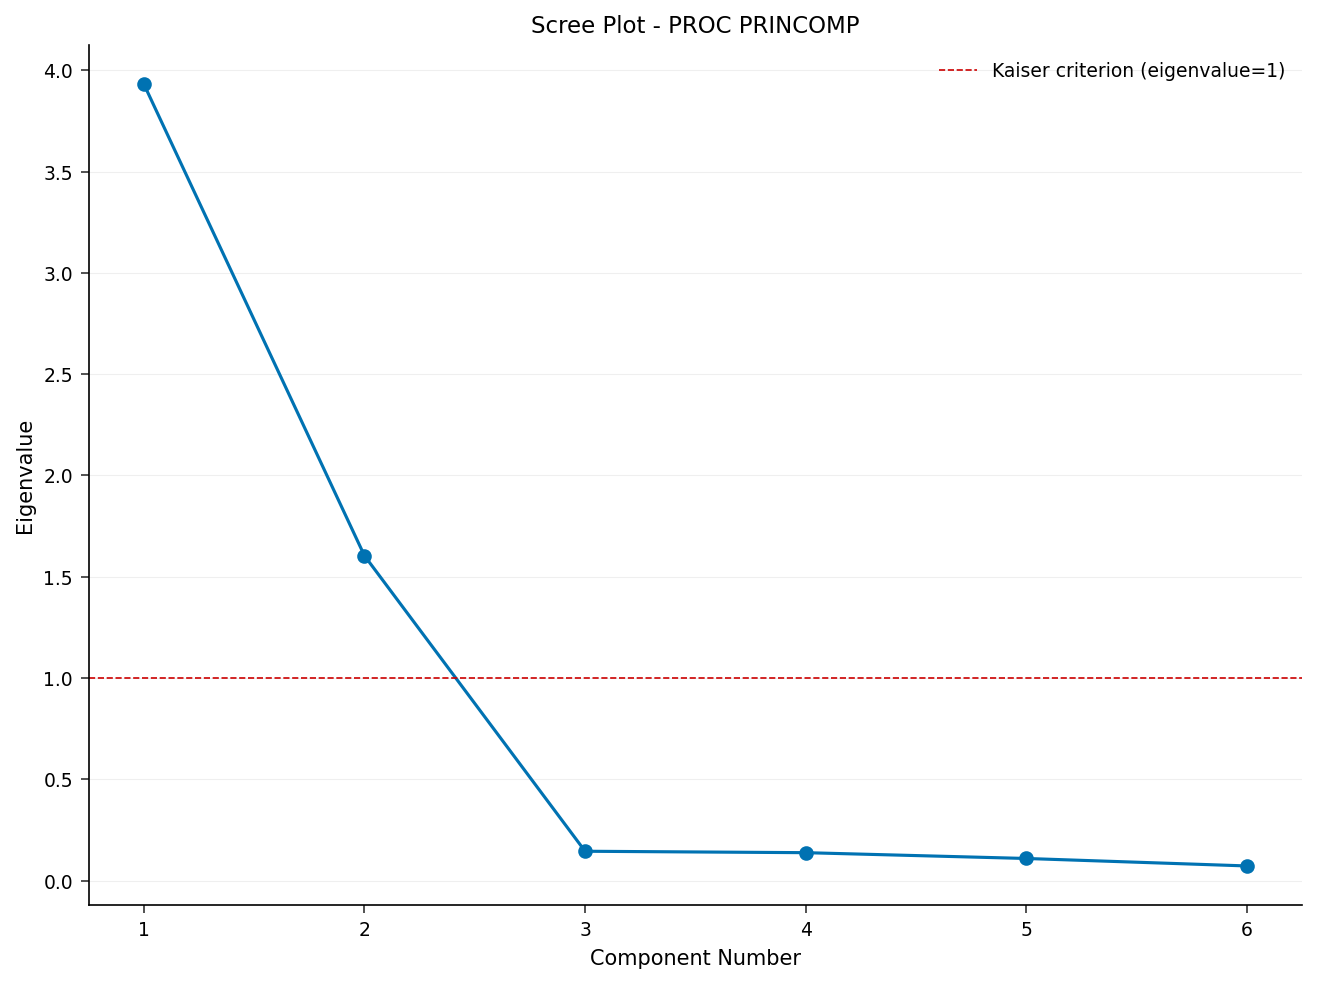

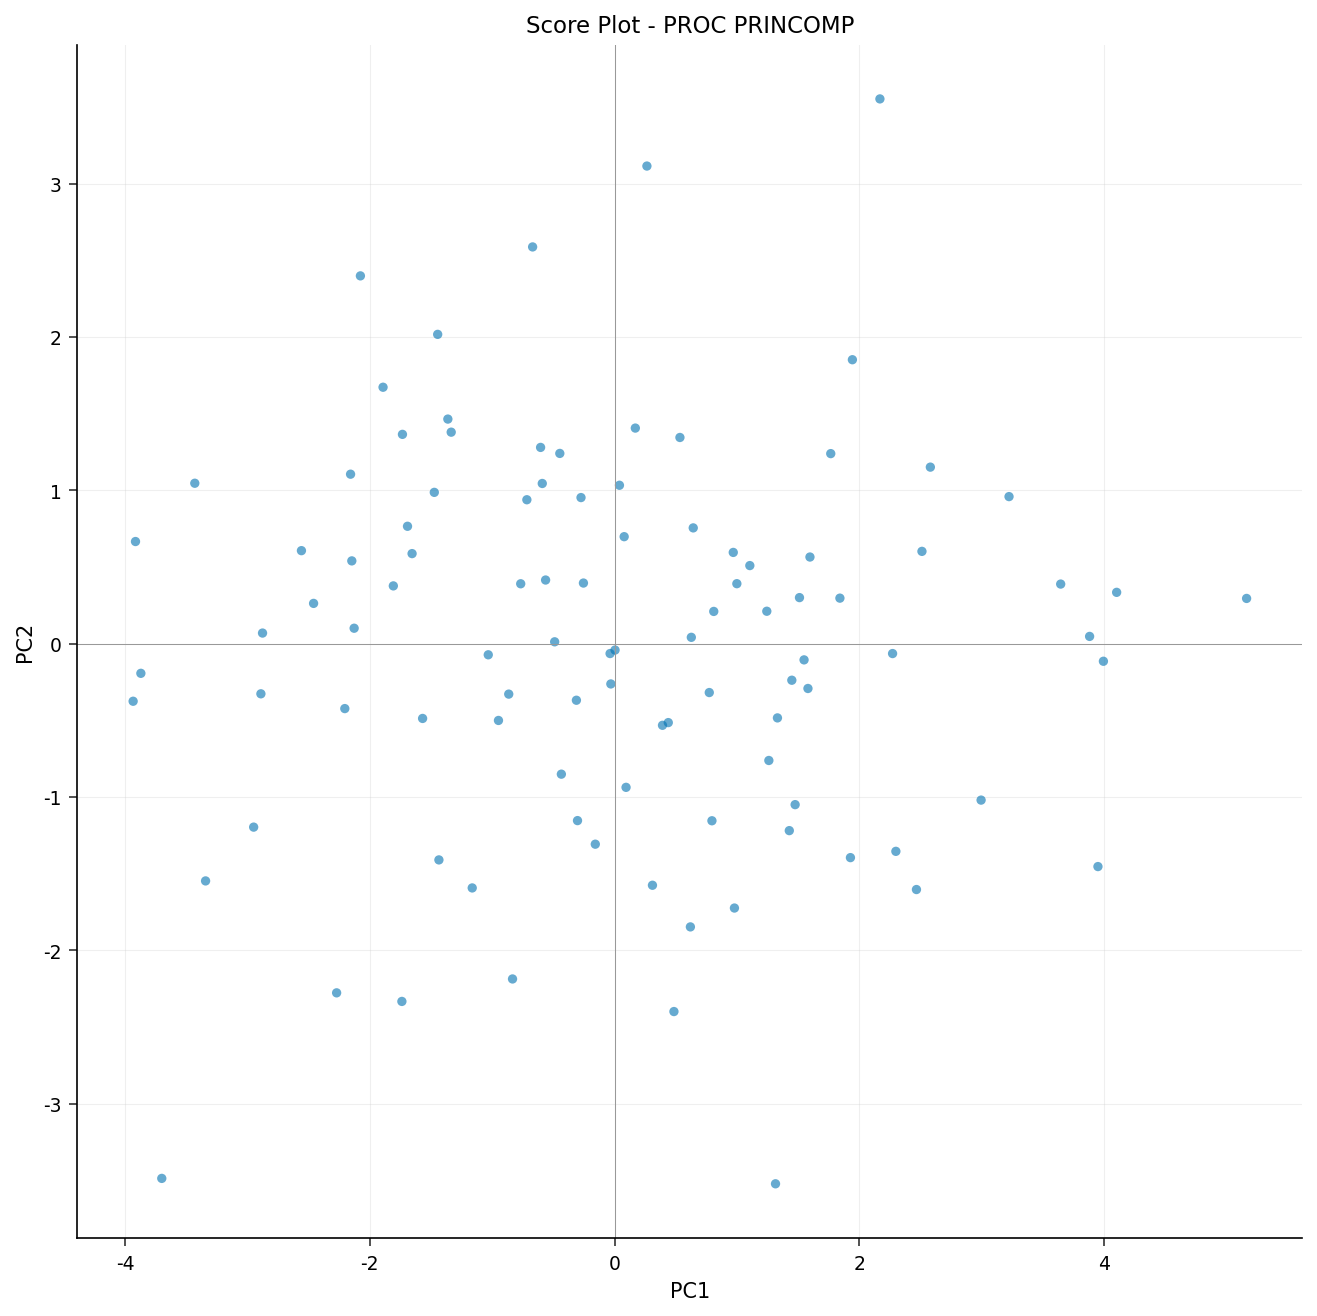

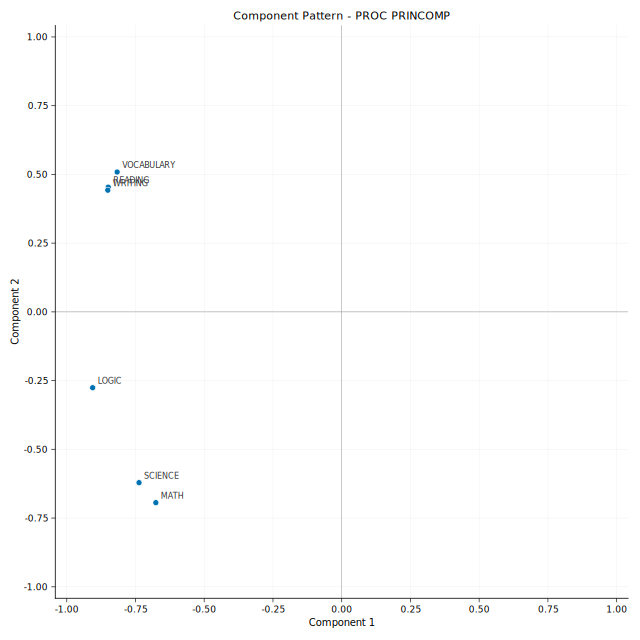

In [3]:
PROCÉDURE PRINCOMP DONNÉES=students PREFIX=SkillPC;
    VAR reading writing vocabulary math science logic;
EXÉCUTER;

## Étape 3 — Retenir les composantes principales et écrire les scores

Guidés par les valeurs propres (nous retenons les composantes dont la valeur propre dépasse 1 et observons le graphique d'éboulis), nous restreignons la solution aux trois premières composantes avec `N=3` et leur donnons un `PREFIX=` descriptif. Nous :

- Utilisons `OUT=` pour écrire les scores de composantes au niveau observation, en reportant `student_id` et `grade` via l'instruction `ID` (le jeu de données `OUT=` n'inclut pas les variables d'analyse d'origine autrement).
- Utilisons `OUTSTAT=` pour capturer les valeurs propres et les vecteurs propres à des fins de documentation et de réutilisation.
- Utilisons `STD` afin que les scores sauvegardés aient une variance unitaire, ce qui est pratique pour un reporting de type centile.

                       The PRINCOMP Procedure

                    Observations         100
                    Variables              6

                       Simple Statistics

Variable            Mean          StdDev

reading        494.46032        38.35596
writing        499.02018        38.28856
vocabulary     495.51805        37.64642
math           499.75555        41.31746
science        500.01392        37.80359
logic          496.47898        33.80841

                    Correlation Matrix

                reading   writing  vocabulary      math   science     logic

reading          1.0000    0.8870      0.8950    0.2589    0.3568    0.6253
writing          0.8870    1.0000      0.8817    0.2601    0.3664    0.6355
vocabulary       0.8950    0.8817      1.0000    0.2267    0.2740    0.5848
math             0.2589    0.2601      0.2267    1.0000    0.8920    0.7710
science          0.3568    0.3664      0.2740    0.8920    1.0000    0.7950
logic            0.6253    0.6355 


NOTE: PROC PRINCOMP data=students

NOTE: Using Python sklearn version 1.8.0
NOTE: Eigenvalues of the Correlation Matrix:
NOTE:   SkillPC1: Eigenvalue=3.932513  Proportion=0.6922  Cumulative=0.6922
NOTE:   SkillPC2: Eigenvalue=1.603834  Proportion=0.2823  Cumulative=0.9745
NOTE:   SkillPC3: Eigenvalue=0.144736  Proportion=0.0255  Cumulative=1.0000
NOTE: Eigenvectors:
NOTE:   Variable       SkillPC1   SkillPC2   SkillPC3
NOTE:   reading        -0.428183    0.358114   -0.218417
NOTE:   writing        -0.429009    0.349423   -0.345339
NOTE:   vocabulary     -0.411844    0.401597    0.330890
NOTE:   math           -0.340844   -0.547991    0.182264
NOTE:   science        -0.371696   -0.490510   -0.595555
NOTE:   logic          -0.456796   -0.217907    0.579345
NOTE: Number of Observations: 100
NOTE: Analysis based on Correlation Matrix
NOTE: ODS plot written: princomp_scree.spec.json
NOTE: ODS plot written: princomp_scores.spec.json
NOTE: ODS plot written: princomp_pattern.spec.json
NOTE: P

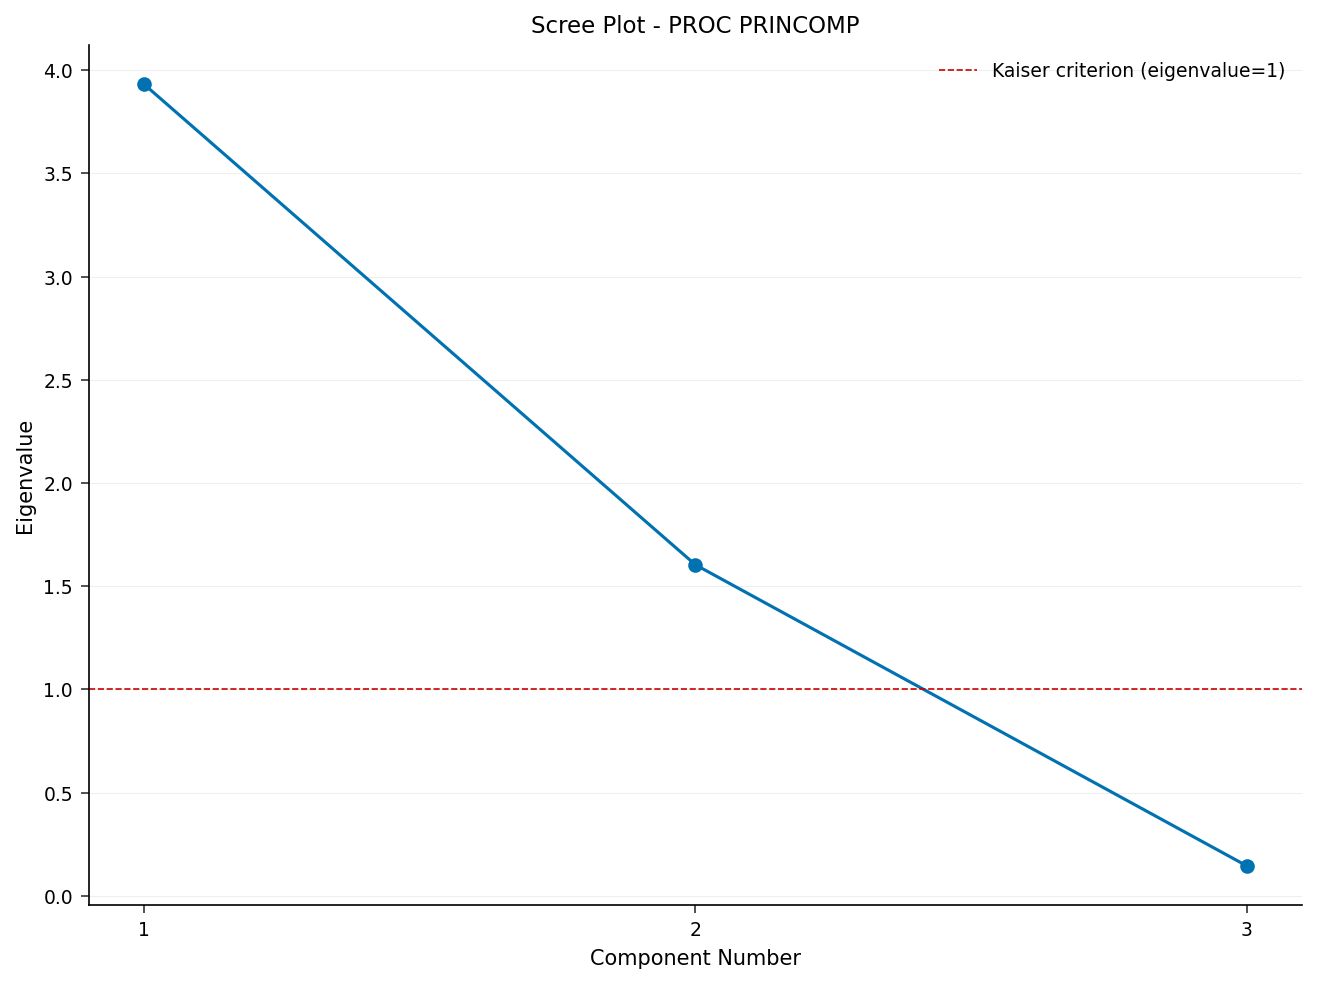

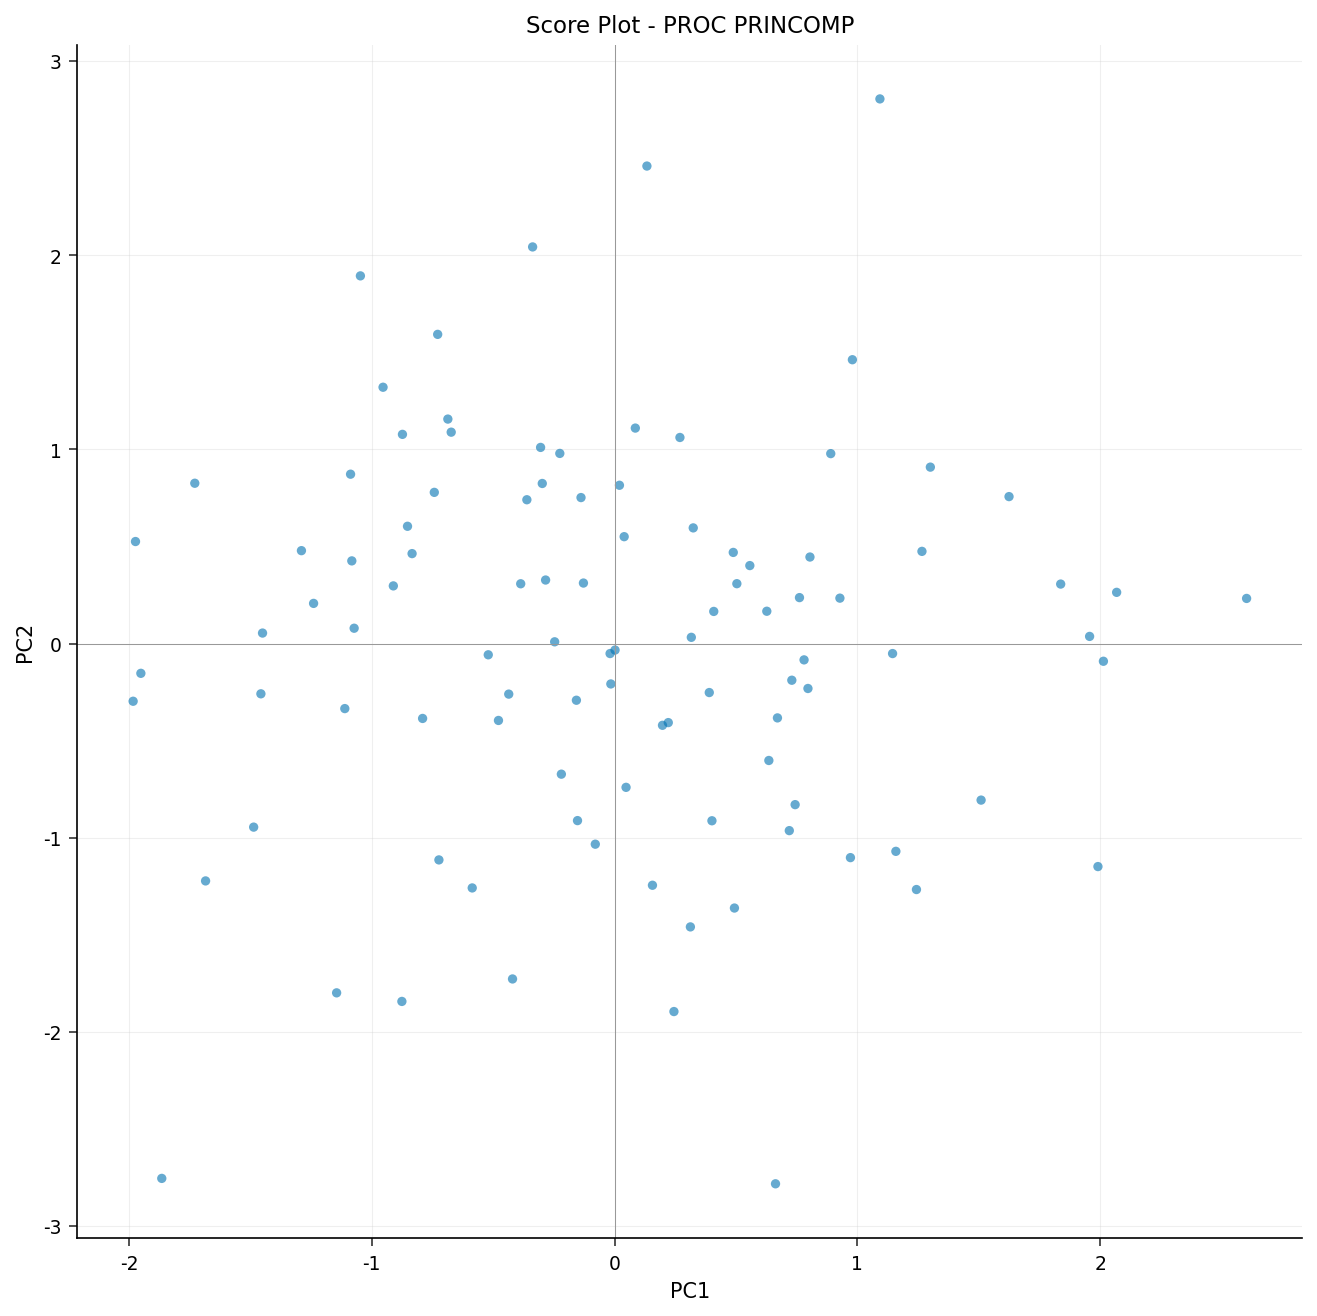

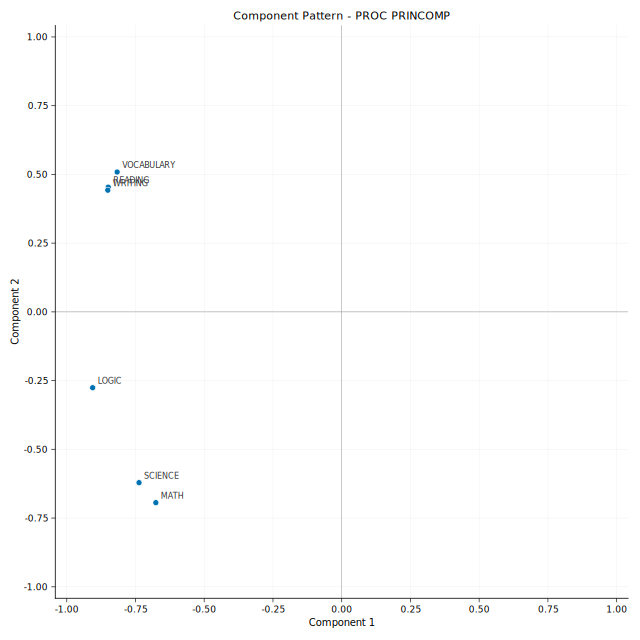

In [4]:
PROCÉDURE PRINCOMP DONNÉES=students
        n=3
        PREFIX=SkillPC
        std
        out=student_scores
        OUTSTAT=pc_stats;
    VAR reading writing vocabulary math science logic;
    id student_id grade;
EXÉCUTER;

In [5]:
PROCÉDURE IMPRIMER DONNÉES=student_scores(obs=8) noobs ÉTIQUETTE;
    TITRE "Scores en composantes principales standardisés par élève";
    VAR student_id grade SkillPC1 SkillPC2 SkillPC3;
    format SkillPC1 SkillPC2 SkillPC3 8.4;
    ÉTIQUETTE student_id="Identifiant élève" grade="Niveau"
        SkillPC1="CP1 (aptitude générale)" SkillPC2="CP2 (verbal/quantitatif)"
        SkillPC3="CP3";
EXÉCUTER;
TITRE;


                                Scores en composantes principales standardisés par élève                                

  Identifiant élève  Niveau    CP1 (aptitude générale)  CP2 (verbal/quantitatif)      CP3
               1001       8                    -0.5206                   -0.0580  -0.1466
               1002       6                     0.5568                    0.4015  -0.1861
               1003       6                    -0.0797                   -1.0333  -1.3074
               1004       7                     0.3158                    0.0320  -0.7336
               1005       8                    -0.7239                   -1.1143  -0.3878
               1006       7                    -1.2401                    0.2067  -1.0722
               1007       7                     2.6031                    0.2323   1.1267
               1008       6                    -0.9116                    0.2968   0.3080

... 92 more observations (showing 8 of 100)




NOTE: PROC PRINT data=student_scores

NOTE: PROC PRINT completed: 8 observations printed, 5 variables


## Étape 4 — Sauvegarder les charges pour noter les futures cohortes

Le district administre la même batterie de tests chaque année. Le jeu de données `OUTSTAT=` de l'étape 3 contient les vecteurs propres ajustés (`_TYPE_='SCORE'`), nous pouvons donc figer ces charges et projeter les élèves de l'année prochaine sur les *mêmes* axes exacts — sans avoir besoin de réajuster le modèle et sans risque de dérive d'axe entre les cohortes. Nous imprimons ici les lignes de vecteurs propres sauvegardées pour confirmer que la règle de notation est capturée et prête à être réutilisée.

In [6]:
PROCÉDURE IMPRIMER DONNÉES=pc_stats noobs ÉTIQUETTE;
    OÙ _TYPE_ = "SCORE";
    TITRE "Charges des vecteurs propres enregistrées (règle de notation pour les cohortes futures)";
    VAR _NAME_ reading writing vocabulary math science logic;
    format reading writing vocabulary math science logic 9.4;
    ÉTIQUETTE _NAME_="Variable" reading="Lecture" writing="Écriture"
        vocabulary="Vocabulaire" math="Mathématiques" science="Sciences" logic="Logique";
EXÉCUTER;
TITRE;


                Charges des vecteurs propres enregistrées (règle de notation pour les cohortes futures)                 

Variable  Lecture   Écriture  Vocabulaire   Mathématiques  Sciences  Logique
SkillPC1  -0.4282    -0.4290      -0.4118         -0.3408   -0.3717  -0.4568
SkillPC2   0.3581     0.3494       0.4016         -0.5480   -0.4905  -0.2179
SkillPC3  -0.2184    -0.3453       0.3309          0.1823   -0.5956   0.5793




NOTE: PROC PRINT data=pc_stats

NOTE: PROC PRINT completed: 3 observations printed, 7 variables


## Étape 5 — Confirmer la structure après élimination de l'effet de l'assiduité

Un sceptique raisonnable pourrait craindre que la composante principale ne reflète simplement le volume d'enseignement reçu par chaque élève. Pour vérifier, nous éliminons l'effet de `attendance_rate` avec l'instruction `PARTIAL`, qui régresse d'abord chaque score de matière sur l'assiduité puis exécute l'ACP sur les résidus. Le bloc de statistiques simples rapporte alors les matières résidualisées (moyenne 0, avec des écarts-types seulement légèrement inférieurs aux scores bruts), et la matrice de corrélation résiduelle montre à quel point la structure inter-matières change peu une fois l'assiduité retirée.

Si la même structure à deux dimensions (aptitude générale + contraste verbal/quantitatif) survit, les composantes sont des dimensions de compétence plutôt qu'un artefact d'exposition.

                       The PRINCOMP Procedure

                    Observations         100
                    Variables              6

                       Simple Statistics

Variable            Mean          StdDev

reading          0.00000        36.07743
writing         -0.00000        35.51634
vocabulary       0.00000        36.10511
math             0.00000        37.75031
science          0.00000        34.37850
logic            0.00000        29.42379

                    Correlation Matrix

                reading   writing  vocabulary      math   science     logic

reading          1.0000    0.8713      0.8856    0.1407    0.2520    0.5596
writing          0.8713    1.0000      0.8721    0.1277    0.2502    0.5593
vocabulary       0.8856    0.8721      1.0000    0.1274    0.1791    0.5336
math             0.1407    0.1277      0.1274    1.0000    0.8701    0.7178
science          0.2520    0.2502      0.1791    0.8701    1.0000    0.7457
logic            0.5596    0.5593 


NOTE: PROC PRINCOMP data=students

NOTE: Using Python sklearn version 1.8.0
NOTE: Eigenvalues of the Correlation Matrix:
NOTE:   AdjPC1: Eigenvalue=3.609907  Proportion=0.6408  Cumulative=0.6408
NOTE:   AdjPC2: Eigenvalue=1.842544  Proportion=0.3271  Cumulative=0.9678
NOTE:   AdjPC3: Eigenvalue=0.181220  Proportion=0.0322  Cumulative=1.0000
NOTE: Eigenvectors:
NOTE:   Variable         AdjPC1     AdjPC2     AdjPC3
NOTE:   reading        -0.440975   -0.341204    0.217589
NOTE:   writing        -0.437947   -0.343127    0.204118
NOTE:   vocabulary     -0.429195   -0.370659   -0.066528
NOTE:   math           -0.309140    0.561122    0.065872
NOTE:   science        -0.348733    0.507056    0.531901
NOTE:   logic          -0.460818    0.237679   -0.786961
NOTE: Number of Observations: 100
NOTE: Analysis based on Correlation Matrix
NOTE: ODS plot written: princomp_scree.spec.json
NOTE: ODS plot written: princomp_scores.spec.json
NOTE: ODS plot written: princomp_pattern.spec.json
NOTE: PROC PR

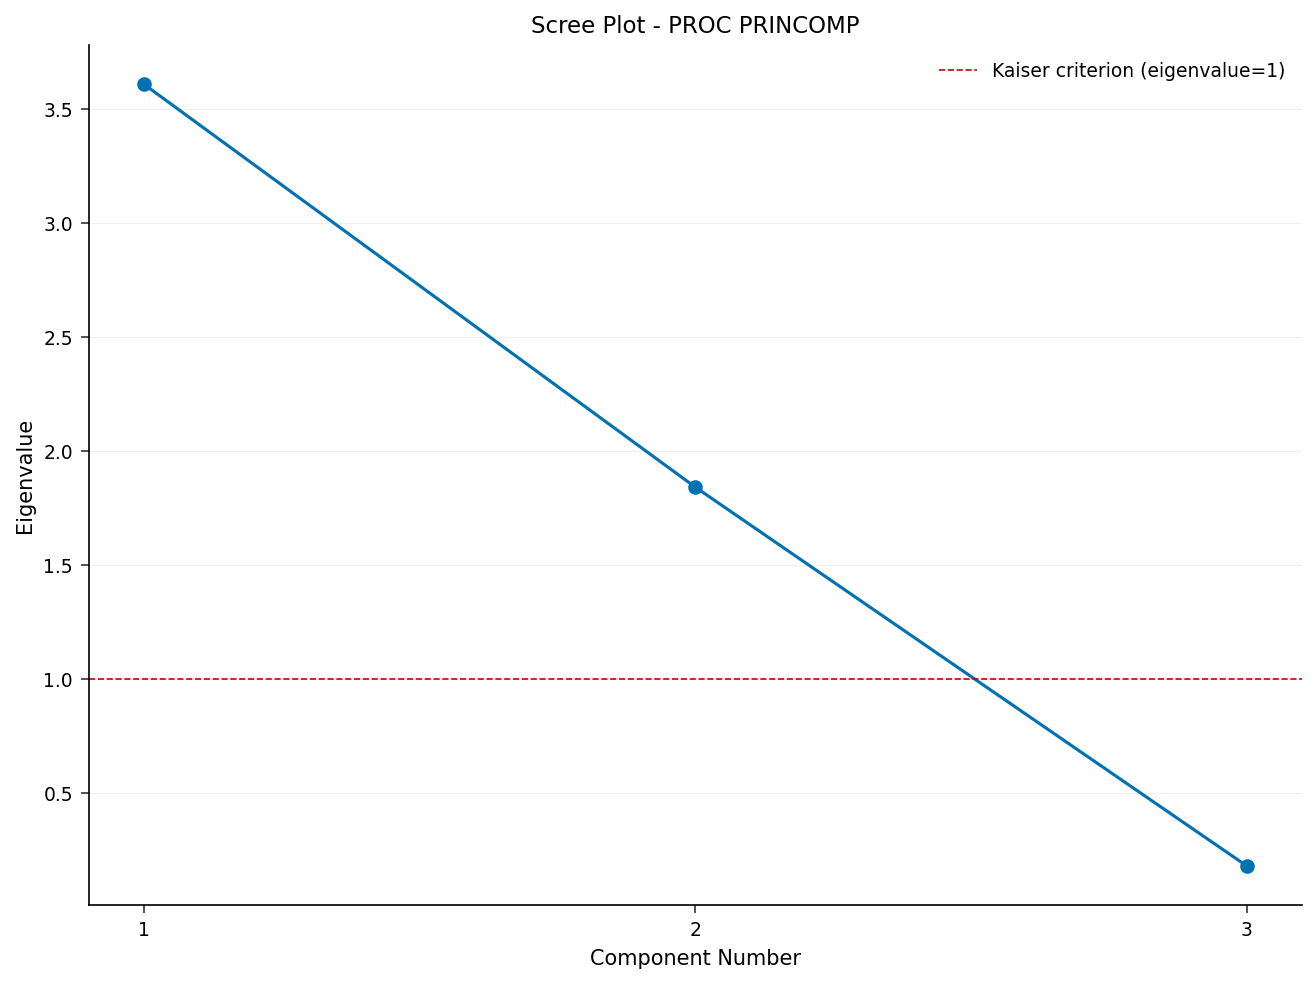

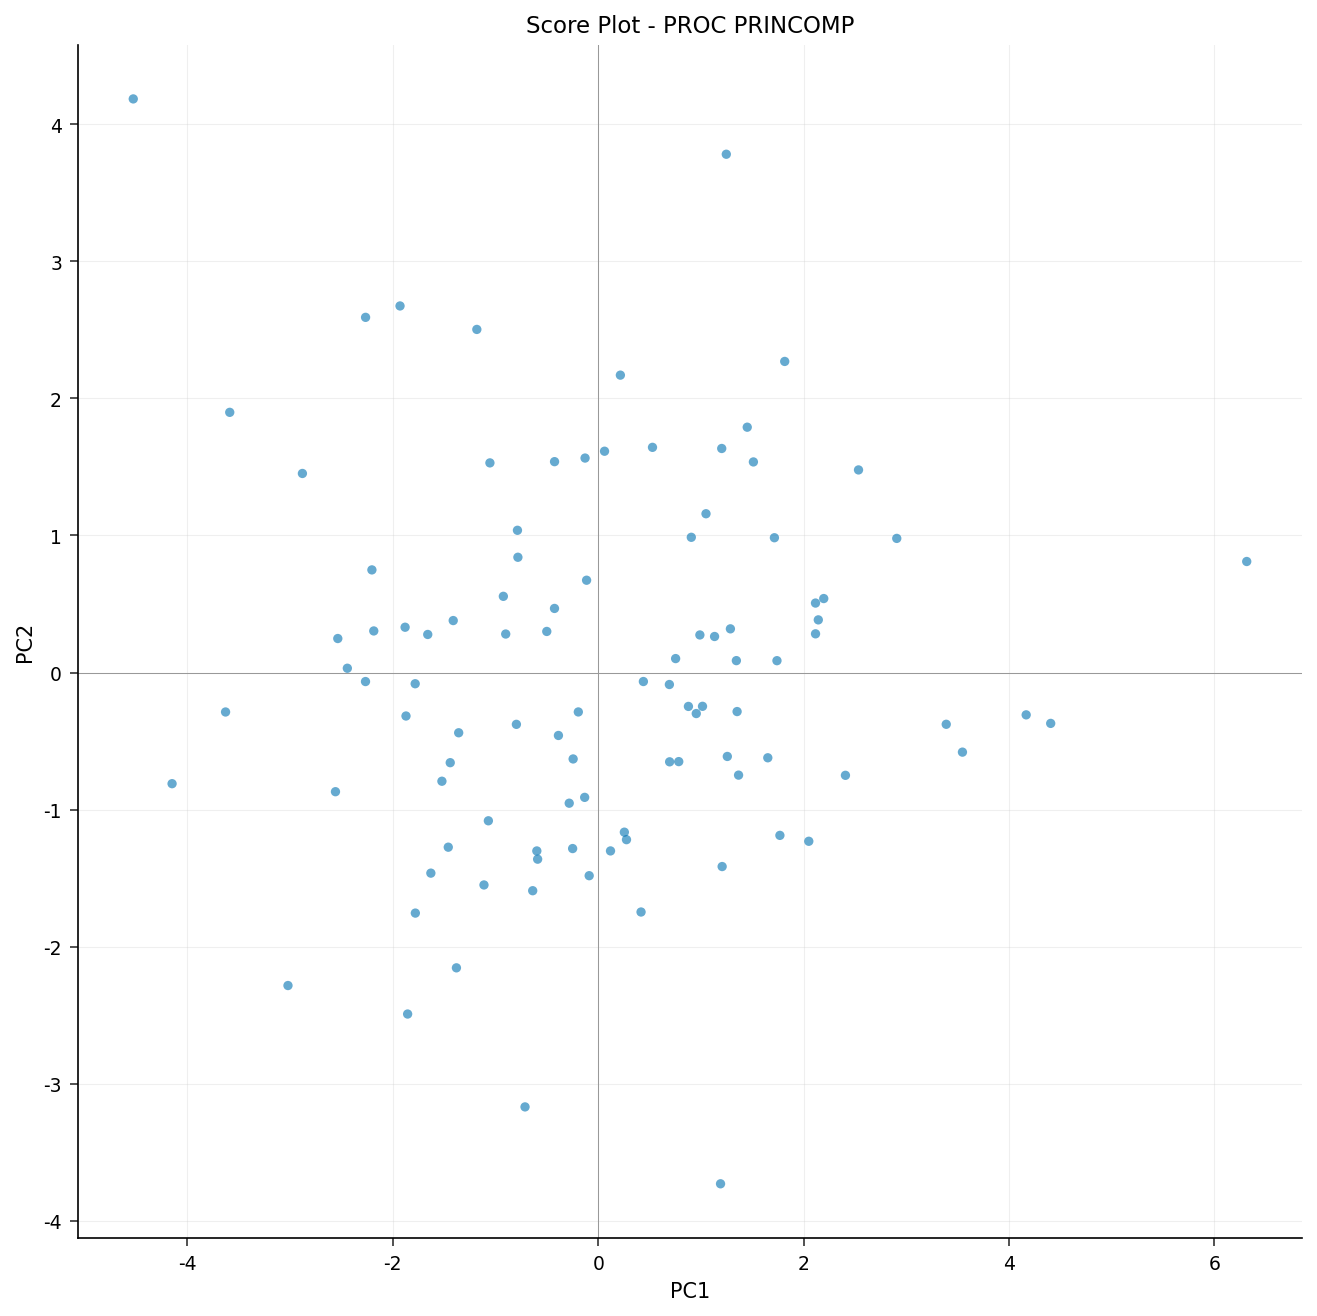

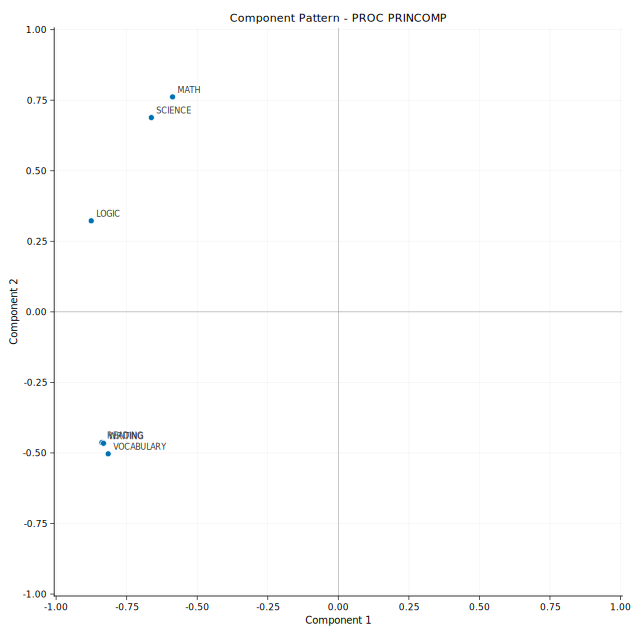

In [7]:
PROCÉDURE PRINCOMP DONNÉES=students n=3 PREFIX=AdjPC;
    VAR reading writing vocabulary math science logic;
    PARTIAL attendance_rate;
EXÉCUTER;

## Interprétation des résultats

- **Un axe dominant (SkillPC1 = aptitude académique générale).** La première composante a une valeur propre de **3,93** et explique **65,5 %** de la variance. Son vecteur propre charge positivement sur *chaque* matière, avec des poids étroitement regroupés entre **0,34 et 0,46** (lecture 0,43, écriture 0,43, vocabulaire 0,41, mathématiques 0,34, sciences 0,37, logique 0,46). Un élève qui obtient un score élevé ici est fort sur l'ensemble des matières ; cet axe unique est un excellent score récapitulatif pour le classement, le suivi de progression, et l'identification des élèves ayant besoin d'un soutien global.

- **Un second axe interprétable (SkillPC2 = verbal vs. quantitatif).** La deuxième composante (valeur propre **1,60**, **26,7 %** de la variance) sépare la batterie par le signe : lecture, écriture et vocabulaire chargent **négativement** (−0,36, −0,35, −0,40) tandis que mathématiques, sciences et logique chargent **positivement** (+0,55, +0,49, +0,22). Deux élèves avec un SkillPC1 identique peuvent différer nettement sur SkillPC2 — l'un à tendance verbale, l'autre à tendance quantitative. C'est exactement la structure à deux facteurs que nous avons intégrée dans les données synthétiques, retrouvée sans en être informé. (Le signe global d'un vecteur propre est arbitraire ; ce qui compte est que les blocs verbal et STEM tombent de côtés opposés.)

- **Deux composantes suffisent.** Seules les deux premières valeurs propres dépassent 1 ; ensemble elles représentent **92,3 %** de la variance (65,5 % + 26,7 %). Les quatre valeurs propres restantes s'effondrent au plancher de bruit — 0,14, 0,14, 0,11 et 0,07 — donc retenir trois composantes dans la sortie des scores est déjà conservateur, et deux suffiraient pour le reporting.

- **Robuste à l'assiduité.** Après élimination de l'effet de `attendance_rate`, l'analyse résiduelle reproduit la même structure à deux dimensions : AdjPC1 (valeur propre **3,61**, **64,1 %**) charge positivement sur les six matières, et AdjPC2 (valeur propre **1,84**, **32,7 %**) sépare à nouveau le bloc verbal (négatif) du bloc STEM (positif). Les écarts-types résiduels rétrécissent à peine (par exemple lecture 38,4 → 36,1, logique 33,8 → 29,4) et les corrélations inter-blocs restent proches de leurs valeurs brutes, donc l'assiduité ne retire qu'une infime part de la variance. Les dimensions de compétence latentes sont intrinsèques aux évaluations, pas un effet secondaire de l'exposition.

- **Réutilisable opérationnellement.** Le jeu de données `OUTSTAT=` capture les vecteurs propres ajustés dans ses lignes `_TYPE_='SCORE'`, donnant au district une règle de notation figée. Chaque nouvelle cohorte peut être projetée sur les mêmes axes exacts à partir de cette matrice de charges sauvegardée — permettant une comparaison directe entre années à partir d'un seul modèle ajusté.

### Lecture des graphiques

- Les **graphiques d'éboulis** rendent la décision de rétention visuelle : la courbe chute de 3,93 à 1,60 puis passe sous la ligne de Kaiser (valeur propre de 1), avec un coude net après la deuxième composante.
- Les **graphiques de scores** placent chacun des 100 élèves dans le plan CP1 x CP2 ; l'exécution `STD` de l'étape 3 remet à l'échelle le nuage de points en variance unitaire, ce qui explique que ses axes soient plus resserrés que ceux du graphique de l'étape 2.
- Les **graphiques de profil de charges** tracent les charges de chaque composante à travers les six matières. La ligne plate qui reste du même signe pour chaque matière est la composante d'aptitude générale ; la ligne qui sépare lecture/écriture/vocabulaire de mathématiques/sciences/logique est le contraste verbal-vs-quantitatif. Ces graphiques de profil adoptent le signe global opposé à celui du tableau des vecteurs propres imprimé — un choix libre en ACP — donc lisez-les par *forme* (plate vs. séparée) plutôt que par le signe brut.